# Notebook 96 - fascicle speckle tracking box-size sweep

Notebook 95 used a `21 x 21 px` square speckle patch, via `SpeckleConfidenceConfig(block_size=21)`.

This notebook repeats the same three-point fascicle speckle-tracking experiment on `june30_4_best` with three square patch sizes:

- `21 x 21 px`: current baseline
- `31 x 31 px`: larger local texture box
- `41 x 41 px`: still larger local texture box

The initial back/center/front points are selected once using the baseline `21 px` setting, then reused for all three patch sizes. That keeps the sweep focused on the texture-analysis box rather than changing the anatomical point locations. Bigger boxes may improve ZNCC robustness, but they also average over a larger tissue region and overlap more between the three points.


In [1]:
from __future__ import annotations

import json
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "ultrasound_tracker").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import (  # noqa: E402
    SpeckleConfidenceConfig,
    compute_speckle_coherence,
    zncc,
    _gray_float,
    _match_patch_at,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames  # noqa: E402
from ultrasound_tracker.geometry import line_length_from_array  # noqa: E402

DATASET_NAME = "june30_4_best"
BOX_SIZES = [21, 31, 41]
SEARCH_RADIUS = 8

OUT_DIR = ROOT / "results" / DATASET_NAME
FIG_DIR = OUT_DIR / "three_point_speckle_box_size_sweep_figures"
COMBINED_CSV_PATH = OUT_DIR / "three_point_speckle_box_size_sweep_tracking.csv"
SUMMARY_CSV_PATH = OUT_DIR / "three_point_speckle_box_size_sweep_summary.csv"
SUMMARY_JSON_PATH = OUT_DIR / "three_point_speckle_box_size_sweep_summary.json"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

POINT_ORDER = ["back", "center", "front"]
POINT_COLORS = {
    "back": "tab:orange",
    "center": "tab:cyan",
    "front": "tab:green",
}
BOX_COLORS = {
    21: "tab:blue",
    31: "tab:purple",
    41: "tab:red",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Project root: {ROOT}")
print(f"Patch sizes: {BOX_SIZES}")


Project root: /Users/grosbedou/PycharmProjects/NDORMS
Patch sizes: [21, 31, 41]


## Load `june30_4_best`

This reuses the saved strict run artifacts rather than re-running the main detector.


In [2]:
def resolve_existing_path(value, fallback: Path | None = None) -> Path:
    candidates = []
    if value:
        p = Path(str(value)).expanduser()
        candidates.append(p if p.is_absolute() else ROOT / p)
        candidates.append(ROOT / p.name)
    if fallback is not None:
        candidates.append(fallback)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    if candidates:
        return candidates[0].resolve()
    raise FileNotFoundError("No path candidate supplied.")


def find_validated_run_dir(name: str) -> Path:
    primary = ROOT / "results" / "strict_ultratimtrack_runs" / name
    if (primary / f"{name}_strict_results.npz").exists():
        return primary.resolve()
    for npz_path in sorted((ROOT / "results").glob(f"**/{name}_strict_results.npz")):
        return npz_path.parent.resolve()
    raise FileNotFoundError(f"Could not find strict results for {name}.")


def finite_scalar(value, default=np.nan) -> float:
    try:
        arr = np.asarray(value, dtype=np.float64).reshape(-1)
        if arr.size and np.isfinite(arr[0]):
            return float(arr[0])
    except Exception:
        pass
    return float(default)


def video_fps_and_count(path: Path) -> tuple[float, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return fps, n_frames


STRICT_RUN_DIR = find_validated_run_dir(DATASET_NAME)
NPZ_PATH = STRICT_RUN_DIR / f"{DATASET_NAME}_strict_results.npz"
METADATA_PATH = STRICT_RUN_DIR / f"{DATASET_NAME}_strict_metadata.json"

metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}
with np.load(NPZ_PATH, allow_pickle=True) as npz:
    arrays = {key: npz[key] for key in npz.files}

VIDEO_PATH = resolve_existing_path(metadata.get("video"), ROOT / "data" / "raw" / f"{DATASET_NAME}.AVI")
ROI_PATH = resolve_existing_path(metadata.get("roi_path"), ROOT / "data" / "rois" / f"{DATASET_NAME}_rois.json")
rois = json.loads(ROI_PATH.read_text()) if ROI_PATH.exists() else {}

fps_cv2, n_video_frames = video_fps_and_count(VIDEO_PATH)
fps = finite_scalar(metadata.get("fps", np.nan), default=fps_cv2)
if not np.isfinite(fps) or fps <= 0:
    fps = fps_cv2 if fps_cv2 > 0 else np.nan

n_from_results = int(np.asarray(arrays.get("frame", [])).reshape(-1).size)
n_to_load = n_from_results if n_from_results > 0 else n_video_frames
frames = read_gray_frames(VIDEO_PATH, limit=n_to_load)
if not frames:
    raise RuntimeError(f"No frames were read from {VIDEO_PATH}")

frame_shape = frames[0].shape[:2]
time_s = np.arange(len(frames), dtype=np.float64) / fps if np.isfinite(fps) and fps > 0 else np.full(len(frames), np.nan)
mm_per_pixel = finite_scalar(arrays.get("mm_per_pixel", metadata.get("mm_per_pixel", np.nan)))
has_mm_calibration = bool(np.isfinite(mm_per_pixel) and mm_per_pixel > 0)
fascicle_roi = tuple(int(v) for v in rois.get("fascicle", (0, 0, frame_shape[1], frame_shape[0])))

print(f"Strict run: {STRICT_RUN_DIR}")
print(f"Video: {VIDEO_PATH}")
print(f"Frames loaded: {len(frames)}; fps={fps}")
print(f"Frame shape: {frame_shape}; fascicle ROI={fascicle_roi}")
print(f"mm_per_pixel: {mm_per_pixel if has_mm_calibration else 'not found'}")


Strict run: /Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/june30_4_best
Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/june30_4_best.AVI
Frames loaded: 84; fps=11.0
Frame shape: (800, 800); fascicle ROI=(180, 107, 442, 228)
mm_per_pixel: 0.063375


## Reference fascicle geometry

Saved strict-run line coordinates are MATLAB-style one-based pixel coordinates, so they are converted to zero-based image coordinates here.


In [3]:
ONE_BASED_OFFSET = np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float64)


def finite_segment(segment) -> bool:
    arr = np.asarray(segment, dtype=np.float64).reshape(-1)
    return arr.size >= 4 and np.all(np.isfinite(arr[:4])) and line_length_from_array(arr[:4]) > 1.0


def reference_fascicle_segment_zero_based(frame_idx: int = 0) -> tuple[np.ndarray, str]:
    for key in ["fascicle_end_segments", "fascicle_segments", "forward_fascicle_end_segments", "selected_seed_segment"]:
        if key not in arrays:
            continue
        arr = np.asarray(arrays[key], dtype=np.float64)
        if arr.ndim == 2 and arr.shape[1] >= 4 and frame_idx < arr.shape[0]:
            seg = arr[frame_idx, :4]
        elif arr.ndim == 1 and arr.size >= 4:
            seg = arr[:4]
        else:
            continue
        if finite_segment(seg):
            return seg - ONE_BASED_OFFSET, key
    meta_seg = metadata.get("selected_seed_segment")
    if meta_seg is not None and finite_segment(meta_seg):
        return np.asarray(meta_seg, dtype=np.float64) - ONE_BASED_OFFSET, "metadata.selected_seed_segment"
    raise RuntimeError("No usable saved fascicle segment found.")


def line_from_array_zero_based(key: str, frame_idx: int = 0) -> np.ndarray | None:
    if key not in arrays:
        return None
    arr = np.asarray(arrays[key], dtype=np.float64)
    if arr.ndim != 2 or frame_idx >= arr.shape[0] or arr.shape[1] < 4:
        return None
    seg = arr[frame_idx, :4]
    if not finite_segment(seg):
        return None
    return seg - ONE_BASED_OFFSET


fascicle_line0, fascicle_source = reference_fascicle_segment_zero_based(0)
p0 = fascicle_line0[:2].astype(np.float64)
p1 = fascicle_line0[2:4].astype(np.float64)
fascicle_length_px = float(np.linalg.norm(p1 - p0))
t_hat = (p1 - p0) / fascicle_length_px
n_hat = np.array([-t_hat[1], t_hat[0]], dtype=np.float64)

sup_apo0 = line_from_array_zero_based("sup_apo_lines", 0)
deep_apo0 = line_from_array_zero_based("deep_apo_lines", 0)

print(f"Reference fascicle source: {fascicle_source}")
print(f"fascicle_length_px={fascicle_length_px:.2f}")
print(f"t_hat={t_hat}, n_hat={n_hat}")


Reference fascicle source: fascicle_end_segments
fascicle_length_px=1139.51
t_hat=[-0.97437006  0.22495106], n_hat=[-0.22495106 -0.97437006]


## Shared tracking helpers

The matcher wraps the same `_match_patch_at` path used by `compute_speckle_coherence` and then computes point-level ZNCC with the public `zncc` helper.


In [4]:
def extract_patch(frame: np.ndarray, point: np.ndarray, block_size: int) -> np.ndarray | None:
    gray = _gray_float(frame)
    half = int(block_size) // 2
    x, y = np.rint(np.asarray(point, dtype=np.float64)).astype(int)
    if x - half < 0 or x + half + 1 > gray.shape[1]:
        return None
    if y - half < 0 or y + half + 1 > gray.shape[0]:
        return None
    return gray[y - half : y + half + 1, x - half : x + half + 1]


def point_to_line_distance(point: np.ndarray, line: np.ndarray) -> float:
    point = np.asarray(point, dtype=np.float64).reshape(2)
    line = np.asarray(line, dtype=np.float64).reshape(4)
    a = line[:2]
    b = line[2:]
    denom = float(np.linalg.norm(b - a))
    if denom <= 1e-12:
        return float("nan")
    return float(abs(np.cross(b - a, point - a)) / denom)


def point_in_roi(point: np.ndarray, roi: tuple[int, int, int, int] | None, margin: float = 0.0) -> bool:
    if roi is None:
        return True
    x, y = [float(v) for v in np.asarray(point).reshape(2)]
    rx, ry, rw, rh = [float(v) for v in roi]
    return (rx + margin) <= x <= (rx + rw - margin) and (ry + margin) <= y <= (ry + rh - margin)


def valid_patch_center(
    point: np.ndarray,
    shape: tuple[int, int],
    cfg: SpeckleConfidenceConfig,
    roi: tuple[int, int, int, int] | None = None,
    aponeurosis_lines: list[np.ndarray | None] | None = None,
) -> bool:
    point = np.asarray(point, dtype=np.float64).reshape(2)
    if not np.all(np.isfinite(point)):
        return False
    half = int(cfg.block_size) // 2
    radius = int(cfg.search_radius)
    margin = half + radius
    height, width = int(shape[0]), int(shape[1])
    x, y = point
    if not (margin <= x <= width - 1 - margin and margin <= y <= height - 1 - margin):
        return False
    if roi is not None and not point_in_roi(point, roi, margin=half):
        return False
    if aponeurosis_lines:
        apo_margin = float(half + 2)
        for line in aponeurosis_lines:
            if line is not None and point_to_line_distance(point, line) < apo_margin:
                return False
    return True


def match_point_once(prev_frame: np.ndarray, curr_frame: np.ndarray, point: np.ndarray, cfg: SpeckleConfidenceConfig) -> dict:
    prev = _gray_float(prev_frame)
    curr = _gray_float(curr_frame)
    forward = _match_patch_at(prev, curr, point, cfg)
    if forward is None:
        return {"ok": False, "point": np.full(2, np.nan), "zncc": np.nan, "cv_score": np.nan}

    matched_point, cv_score = forward
    template = extract_patch(prev, point, int(cfg.block_size))
    matched_patch = extract_patch(curr, matched_point, int(cfg.block_size))
    z = float("nan")
    if template is not None and matched_patch is not None:
        z = zncc(template, matched_patch, min_texture_variance=float(cfg.min_texture_variance))
    if not np.isfinite(z):
        z = float(cv_score)
    return {"ok": True, "point": np.asarray(matched_point, dtype=np.float64), "zncc": float(z), "cv_score": float(cv_score)}


def match_point_with_fb(prev_frame: np.ndarray, curr_frame: np.ndarray, point: np.ndarray, cfg: SpeckleConfidenceConfig) -> dict:
    forward = match_point_once(prev_frame, curr_frame, point, cfg)
    if not forward["ok"]:
        return {**forward, "forward_backward_error": np.nan}
    reverse = match_point_once(curr_frame, prev_frame, forward["point"], cfg)
    if reverse["ok"]:
        fb_error = float(np.linalg.norm(reverse["point"] - np.asarray(point, dtype=np.float64).reshape(2)))
    else:
        fb_error = float("nan")
    return {**forward, "forward_backward_error": fb_error}


def make_cfg(block_size: int) -> SpeckleConfidenceConfig:
    return SpeckleConfidenceConfig(
        block_size=int(block_size),
        stride=24,
        search_radius=SEARCH_RADIUS,
        min_texture_variance=5.0,
        zncc_low=0.45,
        zncc_high=0.90,
        forward_backward_scale_px=2.0,
    )


## Select baseline points once

The same anatomical points are reused across all box sizes. If a larger box made any point invalid, this cell would fail early rather than producing a misleading comparison.


In [5]:
BASE_CFG = make_cfg(21)


def candidate_score_table(frame0, frame1, line, cfg, roi, n_samples=141) -> pd.DataFrame:
    line = np.asarray(line, dtype=np.float64).reshape(4)
    p_start = line[:2]
    p_end = line[2:]
    fractions = np.linspace(0.15, 0.85, int(n_samples))
    rows = []
    apo_lines = [sup_apo0, deep_apo0]
    for fraction in fractions:
        point = p_start + fraction * (p_end - p_start)
        if not valid_patch_center(point, frame0.shape[:2], cfg, roi=roi, aponeurosis_lines=apo_lines):
            continue
        patch = extract_patch(frame0, point, int(cfg.block_size))
        if patch is None:
            continue
        match = match_point_once(frame0, frame1, point, cfg)
        rows.append(
            {
                "fraction": float(fraction),
                "x": float(point[0]),
                "y": float(point[1]),
                "texture_variance": float(np.var(patch)),
                "zncc_0_1": float(match["zncc"]),
            }
        )
    table = pd.DataFrame(rows)
    if table.empty:
        raise RuntimeError("No valid baseline candidate points found.")
    q10, q90 = table["texture_variance"].quantile([0.10, 0.90])
    table["texture_score"] = ((table["texture_variance"] - float(q10)) / max(float(q90 - q10), 1e-12)).clip(0, 1)
    table["zncc_score"] = ((table["zncc_0_1"] - BASE_CFG.zncc_low) / max(BASE_CFG.zncc_high - BASE_CFG.zncc_low, 1e-12)).clip(0, 1)
    table.loc[~np.isfinite(table["zncc_score"]), "zncc_score"] = 0.0
    table["combined_score"] = 0.45 * table["texture_score"] + 0.55 * table["zncc_score"]
    return table.sort_values("combined_score", ascending=False).reset_index(drop=True)


def select_three_points(table: pd.DataFrame, t_axis: np.ndarray, length_px: float, cfg: SpeckleConfidenceConfig):
    center = table.iloc[0][["x", "y"]].to_numpy(dtype=np.float64)
    offset = min(25.0, 0.15 * float(length_px))
    min_offset = max(4.0, float(cfg.block_size // 2))
    apo_lines = [sup_apo0, deep_apo0]
    while offset >= min_offset:
        points = {
            "back": center - offset * t_axis,
            "center": center.copy(),
            "front": center + offset * t_axis,
        }
        if all(valid_patch_center(pt, frame_shape, cfg, roi=fascicle_roi, aponeurosis_lines=apo_lines) for pt in points.values()):
            return points, float(offset)
        offset *= 0.85
    raise RuntimeError("Could not place three valid baseline points.")


baseline_candidates = candidate_score_table(frames[0], frames[1], fascicle_line0, BASE_CFG, fascicle_roi)
initial_points, point_offset_px = select_three_points(baseline_candidates, t_hat, fascicle_length_px, BASE_CFG)

for box_size in BOX_SIZES:
    cfg = make_cfg(box_size)
    for point_id in POINT_ORDER:
        assert valid_patch_center(initial_points[point_id], frame_shape, cfg, roi=fascicle_roi, aponeurosis_lines=[sup_apo0, deep_apo0]), (
            f"{point_id} is invalid for box size {box_size}"
        )

baseline_candidates.to_csv(OUT_DIR / "three_point_box_size_sweep_baseline_candidate_scores.csv", index=False)

print(f"Baseline selected point offset: {point_offset_px:.2f} px")
for point_id in POINT_ORDER:
    print(f"{point_id:>6}: {initial_points[point_id]}")
display(baseline_candidates.head(8))


Baseline selected point offset: 25.00 px
  back: [367.84400129 223.52587801]
center: [343.48474969 229.14965446]
 front: [319.12549809 234.7734309 ]


/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_26561/4076611159.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(abs(np.cross(b - a, point - a)) / denom)
/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_26561/4076611159.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(abs(np.cross(b - a, point - a)) / denom)


,fraction,x,y,texture_variance,zncc_0_1,texture_score,zncc_score,combined_score
0,0.550,343.484750,229.149654,1662.393188,0.987023,1.0,1.0,1.0
1,0.585,304.624076,238.121348,1013.531372,0.967840,1.0,1.0,1.0
2,0.590,299.072551,239.403019,1047.291016,0.970229,1.0,1.0,1.0
3,0.535,360.139324,225.304643,1316.400269,0.987495,1.0,1.0,1.0
4,0.540,354.587799,226.586313,1691.402466,0.989809,1.0,1.0,1.0
5,0.545,349.036274,227.867984,1720.996216,0.987848,1.0,1.0,1.0
6,0.600,287.969502,241.966360,1027.875122,0.982437,1.0,1.0,1.0
7,0.555,337.933225,230.431325,1387.527222,0.984996,1.0,1.0,1.0


## Synthetic checks for each box size


In [6]:
rng = np.random.default_rng(96)
synthetic = rng.normal(loc=128.0, scale=35.0, size=(96, 96)).astype(np.float32)
synthetic = cv2.GaussianBlur(synthetic, (0, 0), sigmaX=1.1)
synthetic = np.clip(synthetic, 0, 255).astype(np.uint8)
known_shift = np.array([4.0, -3.0], dtype=np.float64)
matrix = np.float32([[1, 0, known_shift[0]], [0, 1, known_shift[1]]])
shifted = cv2.warpAffine(synthetic, matrix, (synthetic.shape[1], synthetic.shape[0]), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
synthetic_center = np.array([48.0, 48.0], dtype=np.float64)

synthetic_rows = []
for box_size in BOX_SIZES:
    cfg = make_cfg(box_size)
    match = match_point_with_fb(synthetic, shifted, synthetic_center, cfg)
    recovered_shift = match["point"] - synthetic_center
    synthetic_rows.append(
        {
            "box_size_px": box_size,
            "known_dx": known_shift[0],
            "known_dy": known_shift[1],
            "recovered_dx": recovered_shift[0],
            "recovered_dy": recovered_shift[1],
            "zncc": match["zncc"],
            "forward_backward_error": match["forward_backward_error"],
        }
    )
    assert np.allclose(recovered_shift, known_shift, atol=0.75), f"Synthetic shift failed for box size {box_size}"

synthetic_df = pd.DataFrame(synthetic_rows)
display(synthetic_df)


,box_size_px,known_dx,known_dy,recovered_dx,recovered_dy,zncc,forward_backward_error
0,21,4.0,-3.0,4.0,-3.0,1.0,0.0
1,31,4.0,-3.0,4.0,-3.0,1.0,0.0
2,41,4.0,-3.0,4.0,-3.0,1.0,0.0


## Run the box-size sweep


In [7]:
def track_three_points(frames_in, points0, cfg, max_frames=None):
    n_frames = len(frames_in) if max_frames is None else min(int(max_frames), len(frames_in))
    n_points = len(POINT_ORDER)
    positions = np.full((n_frames, n_points, 2), np.nan, dtype=np.float64)
    dxdy = np.zeros((n_frames, n_points, 2), dtype=np.float64)
    zncc_scores = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    fb_errors = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    valid = np.zeros((n_frames, n_points), dtype=bool)
    fallback_used = np.zeros((n_frames, n_points), dtype=bool)

    for point_idx, point_id in enumerate(POINT_ORDER):
        positions[0, point_idx] = np.asarray(points0[point_id], dtype=np.float64)
        valid[0, point_idx] = True

    last_median_disp = np.zeros(2, dtype=np.float64)
    for frame_idx in range(n_frames - 1):
        attempted_positions = np.full((n_points, 2), np.nan, dtype=np.float64)
        attempted_displacements = np.full((n_points, 2), np.nan, dtype=np.float64)
        pair_good = np.zeros(n_points, dtype=bool)

        for point_idx in range(n_points):
            prev_point = positions[frame_idx, point_idx]
            if not valid_patch_center(prev_point, frames_in[frame_idx].shape[:2], cfg):
                continue
            match = match_point_with_fb(frames_in[frame_idx], frames_in[frame_idx + 1], prev_point, cfg)
            zncc_scores[frame_idx + 1, point_idx] = float(match["zncc"])
            fb_errors[frame_idx + 1, point_idx] = float(match["forward_backward_error"])
            if not match["ok"]:
                continue
            next_point = np.asarray(match["point"], dtype=np.float64)
            disp = next_point - prev_point
            attempted_positions[point_idx] = next_point
            attempted_displacements[point_idx] = disp
            fb_ok = (not np.isfinite(match["forward_backward_error"])) or float(match["forward_backward_error"]) <= cfg.forward_backward_scale_px
            pair_good[point_idx] = bool(float(match["zncc"]) >= cfg.zncc_low and fb_ok)

        if np.any(pair_good):
            fallback_disp = np.nanmedian(attempted_displacements[pair_good], axis=0)
            last_median_disp = fallback_disp.copy()
        else:
            fallback_disp = last_median_disp.copy()

        for point_idx in range(n_points):
            if pair_good[point_idx]:
                positions[frame_idx + 1, point_idx] = attempted_positions[point_idx]
                dxdy[frame_idx + 1, point_idx] = attempted_displacements[point_idx]
                valid[frame_idx + 1, point_idx] = True
            else:
                positions[frame_idx + 1, point_idx] = positions[frame_idx, point_idx] + fallback_disp
                dxdy[frame_idx + 1, point_idx] = fallback_disp
                valid[frame_idx + 1, point_idx] = False
                fallback_used[frame_idx + 1, point_idx] = True

    return {
        "positions": positions,
        "dxdy": dxdy,
        "zncc": zncc_scores,
        "forward_backward_error": fb_errors,
        "valid": valid,
        "fallback_used": fallback_used,
    }


def strain_series(positions: np.ndarray, t_axis: np.ndarray) -> pd.DataFrame:
    back = positions[:, POINT_ORDER.index("back"), :]
    center = positions[:, POINT_ORDER.index("center"), :]
    front = positions[:, POINT_ORDER.index("front"), :]
    lengths = {
        "back_front": np.sum((front - back) * t_axis[None, :], axis=1),
        "back_center": np.sum((center - back) * t_axis[None, :], axis=1),
        "center_front": np.sum((front - center) * t_axis[None, :], axis=1),
    }
    out = pd.DataFrame({"frame": np.arange(positions.shape[0], dtype=int)})
    for name, values in lengths.items():
        initial_length = float(values[0])
        if not np.isfinite(initial_length) or abs(initial_length) < 1e-12:
            out[f"strain_{name}_percent"] = np.nan
            out[f"length_{name}_px"] = values
        else:
            # Negative strain means shortening; positive strain means lengthening.
            out[f"strain_{name}_percent"] = ((values - initial_length) / initial_length) * 100.0
            out[f"length_{name}_px"] = values
    return out


def tracking_dataframe(tracking, cfg, time_values):
    positions = tracking["positions"]
    dxdy = tracking["dxdy"]
    cumulative = positions - positions[0:1, :, :]
    strain_df = strain_series(positions, t_hat).set_index("frame")
    rows = []
    for frame_idx in range(positions.shape[0]):
        strains = strain_df.loc[frame_idx]
        for point_idx, point_id in enumerate(POINT_ORDER):
            cum = cumulative[frame_idx, point_idx]
            step = dxdy[frame_idx, point_idx]
            row = {
                "box_size_px": int(cfg.block_size),
                "search_radius_px": int(cfg.search_radius),
                "frame": int(frame_idx),
                "time_s": float(time_values[frame_idx]) if frame_idx < len(time_values) else np.nan,
                "point_id": point_id,
                "x": float(positions[frame_idx, point_idx, 0]),
                "y": float(positions[frame_idx, point_idx, 1]),
                "dx": float(step[0]),
                "dy": float(step[1]),
                "cumulative_dx": float(cum[0]),
                "cumulative_dy": float(cum[1]),
                "d_parallel_px": float(np.dot(cum, t_hat)),
                "d_perpendicular_px": float(np.dot(cum, n_hat)),
                "zncc": float(tracking["zncc"][frame_idx, point_idx]),
                "forward_backward_error": float(tracking["forward_backward_error"][frame_idx, point_idx]),
                "valid": bool(tracking["valid"][frame_idx, point_idx]),
                "fallback_used": bool(tracking["fallback_used"][frame_idx, point_idx]),
                "strain_back_front_percent": float(strains["strain_back_front_percent"]),
                "strain_back_center_percent": float(strains["strain_back_center_percent"]),
                "strain_center_front_percent": float(strains["strain_center_front_percent"]),
            }
            if has_mm_calibration:
                row.update(
                    {
                        "dx_mm": float(step[0] * mm_per_pixel),
                        "dy_mm": float(step[1] * mm_per_pixel),
                        "cumulative_dx_mm": float(cum[0] * mm_per_pixel),
                        "cumulative_dy_mm": float(cum[1] * mm_per_pixel),
                        "d_parallel_mm": float(np.dot(cum, t_hat) * mm_per_pixel),
                        "d_perpendicular_mm": float(np.dot(cum, n_hat) * mm_per_pixel),
                    }
                )
            rows.append(row)
    return pd.DataFrame(rows)


sweep_trackings = {}
sweep_dfs = []
summary_rows = []

for box_size in BOX_SIZES:
    cfg = make_cfg(box_size)
    print(f"Tracking with {box_size} x {box_size} px patches...")
    tracking = track_three_points(frames, initial_points, cfg)
    df = tracking_dataframe(tracking, cfg, time_s)
    strain = strain_series(tracking["positions"], t_hat)
    sweep_trackings[box_size] = {"cfg": cfg, "tracking": tracking, "strain": strain, "df": df}
    sweep_dfs.append(df)

    invalid_rows = int((~df["valid"]).sum())
    fallback_rows = int(df["fallback_used"].sum())
    invalid_frames = int(df.loc[(~df["valid"]) | df["fallback_used"], "frame"].nunique())
    summary_rows.append(
        {
            "box_size_px": box_size,
            "search_radius_px": SEARCH_RADIUS,
            "mean_zncc": float(df["zncc"].mean(skipna=True)),
            "median_zncc": float(df["zncc"].median(skipna=True)),
            "invalid_rows": invalid_rows,
            "fallback_rows": fallback_rows,
            "invalid_frames": invalid_frames,
            "max_cumulative_displacement_px": float(np.nanmax(np.hypot(df["cumulative_dx"], df["cumulative_dy"]))),
            "peak_abs_longitudinal_strain_percent": float(np.nanmax(np.abs(strain["strain_back_front_percent"]))),
            "peak_longitudinal_strain_percent": float(strain["strain_back_front_percent"].iloc[np.nanargmax(np.abs(strain["strain_back_front_percent"]))]),
        }
    )

combined_df = pd.concat(sweep_dfs, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values("box_size_px")

combined_df.to_csv(COMBINED_CSV_PATH, index=False)
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
SUMMARY_JSON_PATH.write_text(json.dumps(summary_df.to_dict(orient="records"), indent=2))

print(f"Saved combined CSV: {COMBINED_CSV_PATH}")
print(f"Saved summary CSV: {SUMMARY_CSV_PATH}")
display(summary_df)


Tracking with 21 x 21 px patches...


Tracking with 31 x 31 px patches...


Tracking with 41 x 41 px patches...


Saved combined CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_tracking.csv
Saved summary CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_summary.csv


,box_size_px,search_radius_px,mean_zncc,median_zncc,invalid_rows,fallback_rows,invalid_frames,max_cumulative_displacement_px,peak_abs_longitudinal_strain_percent,peak_longitudinal_strain_percent
0,21,8,0.878139,0.903314,60,60,44,61.914899,28.768487,28.768487
1,31,8,0.890710,0.915203,37,37,29,59.833669,35.514512,35.514512
2,41,8,0.912988,0.926079,33,33,23,72.168729,30.267325,30.267325


## Figures


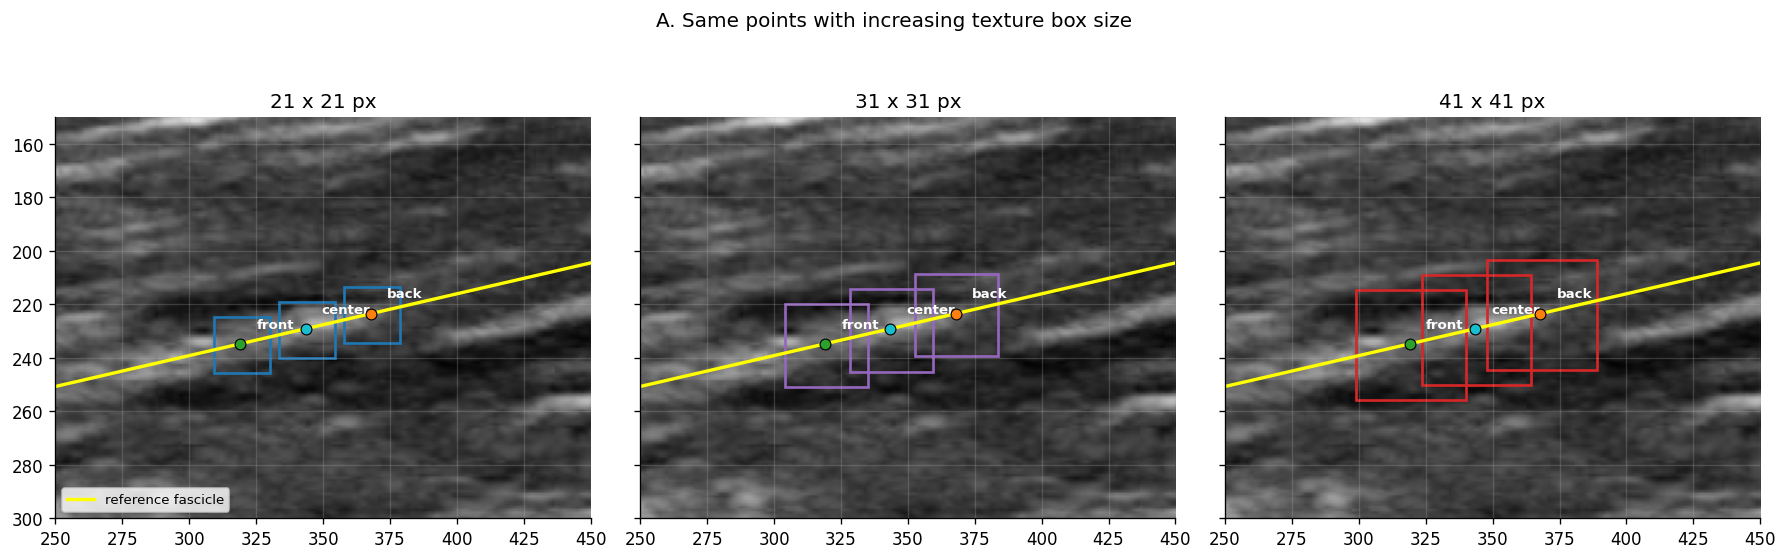

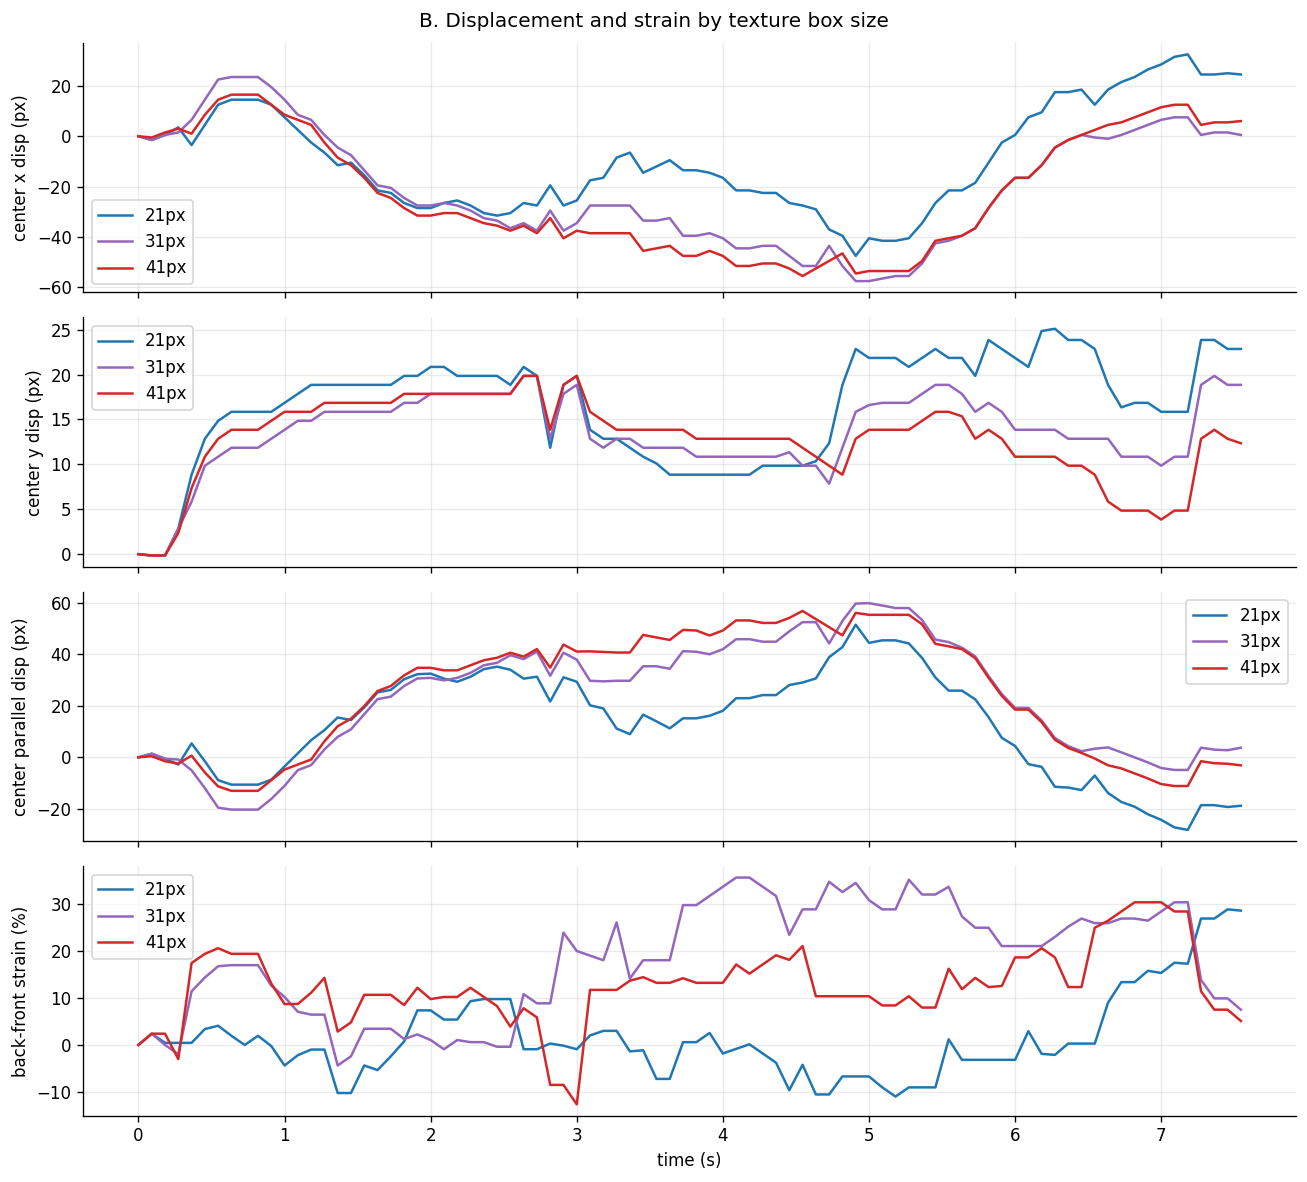

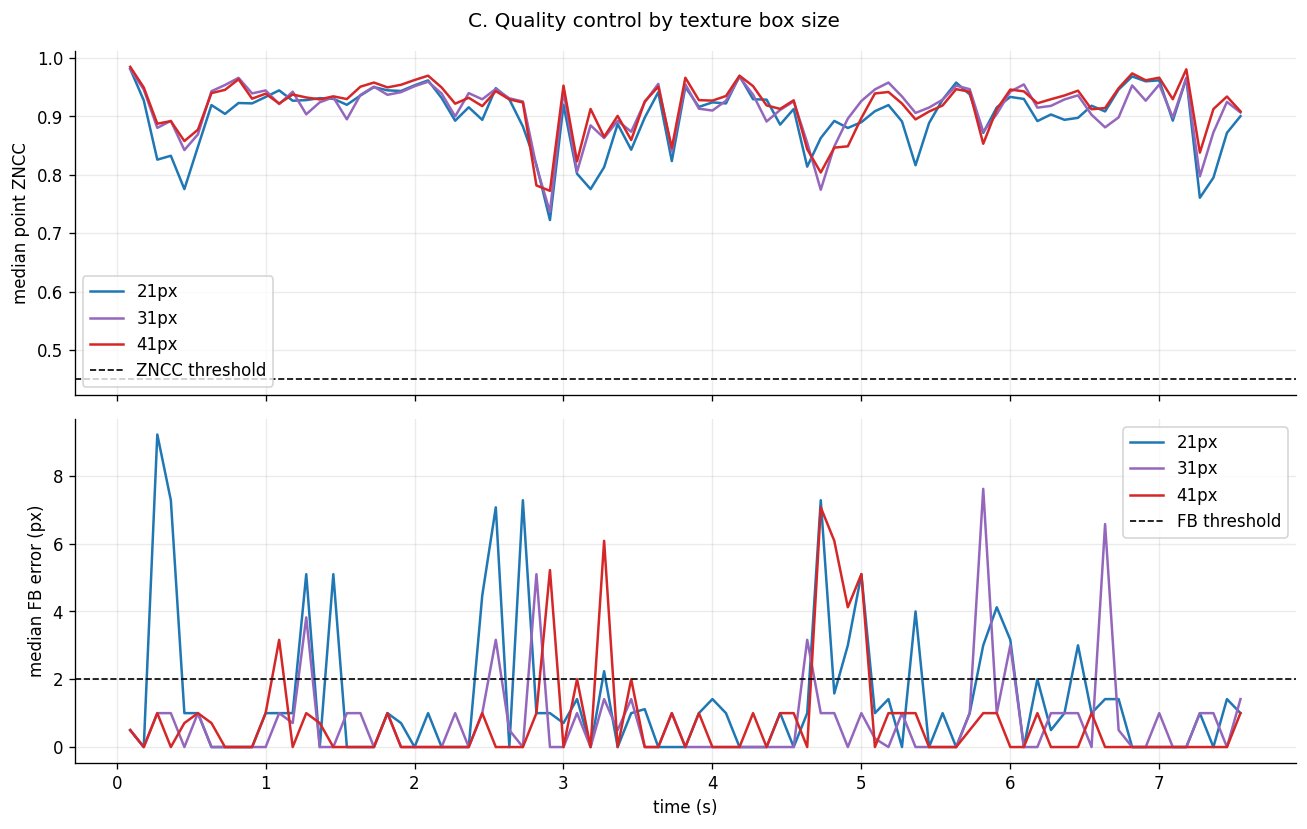

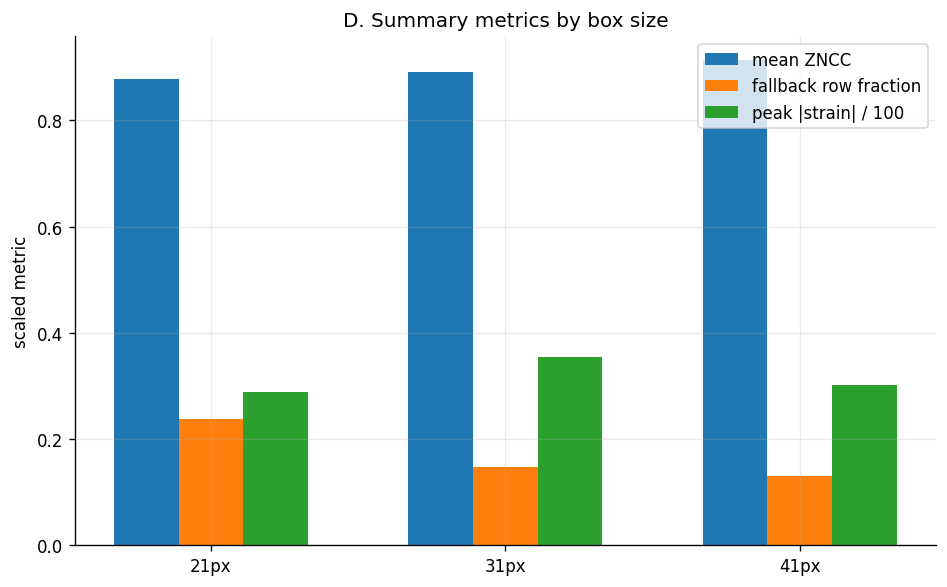

Saved figures:
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures/A_reference_boxes_by_size.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures/B_displacement_strain_by_box_size.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures/C_quality_by_box_size.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures/D_summary_metrics_by_box_size.png


In [8]:
def plot_line(ax, line, color, label=None, linewidth=2.0, linestyle="-"):
    if line is None:
        return
    ax.plot([line[0], line[2]], [line[1], line[3]], color=color, linewidth=linewidth, linestyle=linestyle, label=label)


def draw_patch_box(ax, point, block_size, color, linewidth=1.4):
    half = int(block_size) // 2
    ax.add_patch(
        Rectangle(
            (float(point[0]) - half, float(point[1]) - half),
            int(block_size),
            int(block_size),
            fill=False,
            edgecolor=color,
            linewidth=linewidth,
        )
    )


fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, box_size in zip(axes, BOX_SIZES):
    ax.imshow(frames[0], cmap="gray", vmin=0, vmax=255)
    plot_line(ax, fascicle_line0, color="yellow", label="reference fascicle", linewidth=2.0)
    for point_id in POINT_ORDER:
        point = initial_points[point_id]
        draw_patch_box(ax, point, box_size, BOX_COLORS[box_size], linewidth=1.6)
        ax.scatter(point[0], point[1], s=42, color=POINT_COLORS[point_id], edgecolor="black", linewidth=0.7, zorder=5)
        ax.text(point[0] + 6, point[1] - 6, point_id, color="white", fontsize=8, weight="bold")
    ax.set_title(f"{box_size} x {box_size} px")
    ax.set_xlim(250, 450)
    ax.set_ylim(300, 150)
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("A. Same points with increasing texture box size")
fig.tight_layout()
fig_a_path = FIG_DIR / "A_reference_boxes_by_size.png"
fig.savefig(fig_a_path)
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for box_size in BOX_SIZES:
    df = sweep_trackings[box_size]["df"]
    strain = sweep_trackings[box_size]["strain"]
    center = df[df["point_id"] == "center"]
    color = BOX_COLORS[box_size]
    axes[0].plot(center["time_s"], center["cumulative_dx"], label=f"{box_size}px", color=color)
    axes[1].plot(center["time_s"], center["cumulative_dy"], label=f"{box_size}px", color=color)
    axes[2].plot(center["time_s"], center["d_parallel_px"], label=f"{box_size}px", color=color)
    axes[3].plot(time_s, strain["strain_back_front_percent"], label=f"{box_size}px", color=color)
axes[0].set_ylabel("center x disp (px)")
axes[1].set_ylabel("center y disp (px)")
axes[2].set_ylabel("center parallel disp (px)")
axes[3].set_ylabel("back-front strain (%)")
axes[3].set_xlabel("time (s)")
for ax in axes:
    ax.legend(loc="best")
fig.suptitle("B. Displacement and strain by texture box size")
fig.tight_layout()
fig_b_path = FIG_DIR / "B_displacement_strain_by_box_size.png"
fig.savefig(fig_b_path)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for box_size in BOX_SIZES:
    df = sweep_trackings[box_size]["df"]
    per_frame = (
        df.groupby("frame")
        .agg(
            time_s=("time_s", "first"),
            median_zncc=("zncc", "median"),
            median_fb=("forward_backward_error", "median"),
            fallback_any=("fallback_used", "max"),
            invalid_any=("valid", lambda s: not bool(np.all(s))),
        )
        .reset_index()
    )
    color = BOX_COLORS[box_size]
    axes[0].plot(per_frame["time_s"], per_frame["median_zncc"], label=f"{box_size}px", color=color)
    axes[1].plot(per_frame["time_s"], per_frame["median_fb"], label=f"{box_size}px", color=color)
axes[0].axhline(0.45, color="black", linestyle="--", linewidth=1, label="ZNCC threshold")
axes[1].axhline(2.0, color="black", linestyle="--", linewidth=1, label="FB threshold")
axes[0].set_ylabel("median point ZNCC")
axes[1].set_ylabel("median FB error (px)")
axes[1].set_xlabel("time (s)")
axes[0].legend(loc="best")
axes[1].legend(loc="best")
fig.suptitle("C. Quality control by texture box size")
fig.tight_layout()
fig_c_path = FIG_DIR / "C_quality_by_box_size.png"
fig.savefig(fig_c_path)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary_df))
width = 0.22
ax.bar(x - width, summary_df["mean_zncc"], width=width, label="mean ZNCC")
ax.bar(x, summary_df["fallback_rows"] / (len(frames) * len(POINT_ORDER)), width=width, label="fallback row fraction")
ax.bar(x + width, summary_df["peak_abs_longitudinal_strain_percent"] / 100.0, width=width, label="peak |strain| / 100")
ax.set_xticks(x)
ax.set_xticklabels([f"{v}px" for v in summary_df["box_size_px"]])
ax.set_ylabel("scaled metric")
ax.set_title("D. Summary metrics by box size")
ax.legend(loc="best")
fig.tight_layout()
fig_d_path = FIG_DIR / "D_summary_metrics_by_box_size.png"
fig.savefig(fig_d_path)
plt.show()

print("Saved figures:")
for path in [fig_a_path, fig_b_path, fig_c_path, fig_d_path]:
    print(path)


## Overlay videos for 31 px and 41 px boxes

These videos use the already-computed sweep tracking results, so the overlays match the CSV and figures exactly. Each frame shows the reference fascicle, current tracked positions, trails, current patch boxes, and the current back-front longitudinal strain.


In [9]:

OVERLAY_BOX_SIZES = [31, 41]


def gray_to_bgr(frame: np.ndarray) -> np.ndarray:
    arr = np.asarray(frame)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR) if arr.ndim == 2 else arr.copy()


def point_color_bgr(point_id: str) -> tuple[int, int, int]:
    return {
        "back": (0, 165, 255),
        "center": (255, 255, 0),
        "front": (0, 200, 0),
    }[point_id]


def box_color_bgr(box_size: int) -> tuple[int, int, int]:
    return {
        21: (255, 120, 40),
        31: (190, 80, 190),
        41: (60, 60, 255),
    }.get(int(box_size), (255, 255, 255))


def draw_patch_box_cv2(vis: np.ndarray, point: np.ndarray, box_size: int, color: tuple[int, int, int]) -> None:
    half = int(box_size) // 2
    x, y = np.rint(point).astype(int)
    cv2.rectangle(vis, (x - half, y - half), (x + half, y + half), color, 2, cv2.LINE_AA)


def write_sweep_overlay_video(box_size: int) -> Path:
    if box_size not in sweep_trackings:
        raise KeyError(f"No tracking results for box size {box_size}")

    tracking = sweep_trackings[box_size]["tracking"]
    strain = sweep_trackings[box_size]["strain"]
    output_path = FIG_DIR / f"three_point_speckle_overlay_{box_size}px.mp4"
    height, width = frames[0].shape[:2]
    video_fps = fps if np.isfinite(fps) and fps > 0 else 10.0
    writer = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*"mp4v"), video_fps, (width, height))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open video writer for {output_path}")

    line_int = np.rint(fascicle_line0).astype(int)
    patch_color = box_color_bgr(box_size)
    for frame_idx, frame in enumerate(frames):
        vis = gray_to_bgr(frame)
        cv2.line(vis, (line_int[0], line_int[1]), (line_int[2], line_int[3]), (0, 255, 255), 2, cv2.LINE_AA)

        for point_idx, point_id in enumerate(POINT_ORDER):
            pts = tracking["positions"][: frame_idx + 1, point_idx, :]
            point_color = point_color_bgr(point_id)
            for a, b in zip(pts[:-1], pts[1:]):
                if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
                    cv2.line(vis, tuple(np.rint(a).astype(int)), tuple(np.rint(b).astype(int)), point_color, 2, cv2.LINE_AA)
            p = tracking["positions"][frame_idx, point_idx]
            if np.all(np.isfinite(p)):
                draw_patch_box_cv2(vis, p, box_size, patch_color)
                cv2.circle(vis, tuple(np.rint(p).astype(int)), 6, point_color, -1, cv2.LINE_AA)
                cv2.circle(vis, tuple(np.rint(p).astype(int)), 7, (0, 0, 0), 1, cv2.LINE_AA)
                label_xy = tuple((np.rint(p).astype(int) + np.array([8, -8])).tolist())
                cv2.putText(vis, point_id, label_xy, cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
                cv2.putText(vis, point_id, label_xy, cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        strain_value = float(strain.loc[frame_idx, "strain_back_front_percent"])
        text_lines = [
            f"{box_size} x {box_size} px texture box",
            f"frame {frame_idx:03d}  BF strain {strain_value:+.2f}%",
        ]
        for line_no, text in enumerate(text_lines):
            y = 32 + 30 * line_no
            cv2.putText(vis, text, (18, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(vis, text, (18, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 1, cv2.LINE_AA)
        writer.write(vis)

    writer.release()
    return output_path


overlay_video_paths = [write_sweep_overlay_video(box_size) for box_size in OVERLAY_BOX_SIZES]
print("Saved overlay videos:")
for path in overlay_video_paths:
    print(path)


Saved overlay videos:
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures/three_point_speckle_overlay_31px.mp4
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures/three_point_speckle_overlay_41px.mp4


## Short conclusion


In [10]:
best_zncc = summary_df.loc[summary_df["mean_zncc"].idxmax()]
fewest_fallback = summary_df.loc[summary_df["fallback_rows"].idxmin()]
smallest_peak_strain = summary_df.loc[summary_df["peak_abs_longitudinal_strain_percent"].idxmin()]

display(
    Markdown(
        f'''
        - Current texture-analysis box in notebook 95: **21 x 21 px**.
        - Highest mean ZNCC in this sweep: **{int(best_zncc["box_size_px"])} x {int(best_zncc["box_size_px"])} px**.
        - Fewest fallback rows: **{int(fewest_fallback["box_size_px"])} x {int(fewest_fallback["box_size_px"])} px**.
        - Smallest peak absolute back-front strain: **{int(smallest_peak_strain["box_size_px"])} x {int(smallest_peak_strain["box_size_px"])} px**.

        Interpretation caution: larger boxes often raise correlation by including more texture, but the three boxes overlap more strongly and can smooth or couple the point motions. The best scientific choice is therefore not simply the highest ZNCC; use the overlay, fallback rate, and strain plausibility together.

        Outputs:

        - Combined tracking CSV: `{COMBINED_CSV_PATH}`
        - Summary CSV: `{SUMMARY_CSV_PATH}`
        - Figures: `{FIG_DIR}`
        '''
    )
)



        - Current texture-analysis box in notebook 95: **21 x 21 px**.
        - Highest mean ZNCC in this sweep: **41 x 41 px**.
        - Fewest fallback rows: **41 x 41 px**.
        - Smallest peak absolute back-front strain: **21 x 21 px**.

        Interpretation caution: larger boxes often raise correlation by including more texture, but the three boxes overlap more strongly and can smooth or couple the point motions. The best scientific choice is therefore not simply the highest ZNCC; use the overlay, fallback rate, and strain plausibility together.

        Outputs:

        - Combined tracking CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_tracking.csv`
        - Summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_summary.csv`
        - Figures: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_box_size_sweep_figures`
        